<h1> Логистическая регрессия c SVM<h1>

<h1> Для примера будет взят датасет с вином из 16-го домашнего задания, там же был проведен EDA анализ<h1>

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets, linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

In [27]:
wine = datasets.load_wine(as_frame = False)
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

In [28]:
#selected_columns = ['flavanoids', 'target']
selected_columns = ['flavanoids', 'color_intensity']
df_selected = df[selected_columns]
df_target = df['target']

In [29]:
X = df_selected
y = df_target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train

158    2
137    2
98     1
159    2
38     0
      ..
71     1
106    1
14     0
92     1
102    1
Name: target, Length: 142, dtype: int32

In [30]:
model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:15])

[0 0 2 0 0 0 1 2 1 2 1 2 0 1 0]


In [31]:
# результат с выбранными столбцами
accuracy = accuracy_score(y_test,predictions)*100

confusion_mat = confusion_matrix(y_test,predictions)

print("Accuracy is",accuracy)
print("Confusion Matrix")
print(confusion_mat)

Accuracy is 88.88888888888889
Confusion Matrix
[[13  1  0]
 [ 3 11  0]
 [ 0  0  8]]


In [32]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [33]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8888888888888888


<h1> Linear regression with SVM<h1>

In [35]:
X = np.array([42.9, 68.2, 74.1, 73.5, 94.8, 163, 63.2, 48.7, 61.4, 75.5, 61.9, 58.2, 75, 41.2, 179, 83.3, 99.6, 144, 56.4, 59.1, 250, 251, 
              42.1, 240, 50, 51, 100, 67, 41.3])
y = np.array([137591, 155504, 332660, 196840, 275576, 246050, 121057, 95271, 107278, 173022, 168298, 98223, 122041, 112337, 285418, 344470, 222429, 423206, 
              152551, 305102, 332660, 840507, 86177, 984200, 167117, 122041, 472416, 234240, 74799])

X = np.array(X).reshape(-1, 1)
y = np.array(y).reshape(-1, 1)

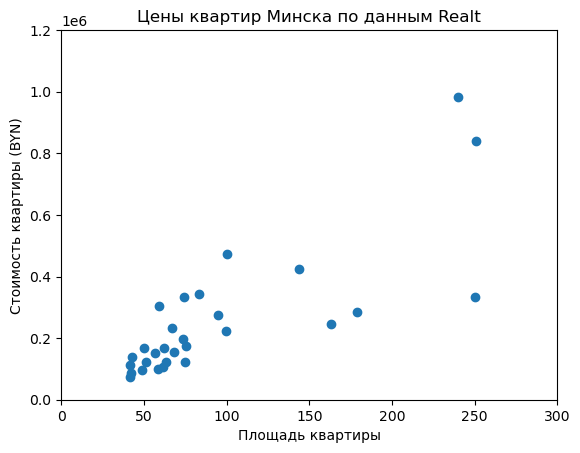

In [36]:
plt.scatter(x=X, y=y)

plt.xlabel("Площадь квартиры")
plt.ylabel("Стоимость квартиры (BYN)")
plt.title("Цены квартир Минска по данным Realt")
plt.xlim(0, 300)
plt.ylim(0, 1200000)

plt.show()

In [68]:
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

regr = LinearRegression()
 
regr.fit(X_train, y_train)
print(regr.score(X_test, y_test))

0.8292981624689567


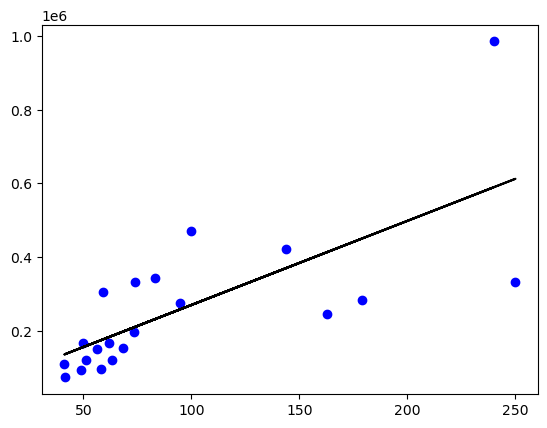

In [38]:
y_pred = regr.predict(X_train)
plt.scatter(X_train, y_train, color ='b')
plt.plot(X_train, y_pred, color ='k')
 
plt.show()

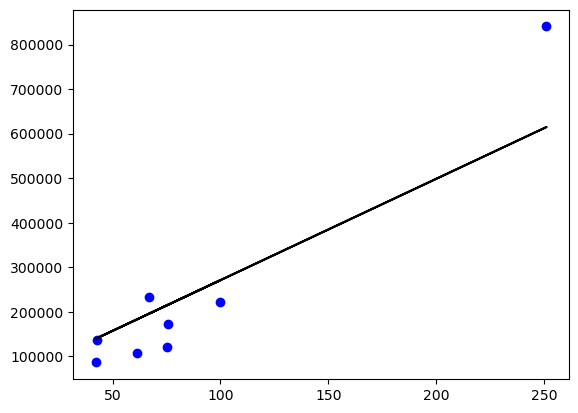

In [39]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color ='b')
plt.plot(X_test, y_pred, color ='k')
 
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
 
y_pred = regr.predict(X_test)    
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
#squared True returns MSE value, False returns RMSE value.
mse = mean_squared_error(y_true=y_test,y_pred=y_pred) #default=True
rmse = mean_squared_error(y_true=y_test,y_pred=y_pred,squared=False)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)

MAE: 72322.157458243
MSE: 9198990836.8971
RMSE: 95911.36969565756


<h1> SVM Linear Kernel<h1>

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


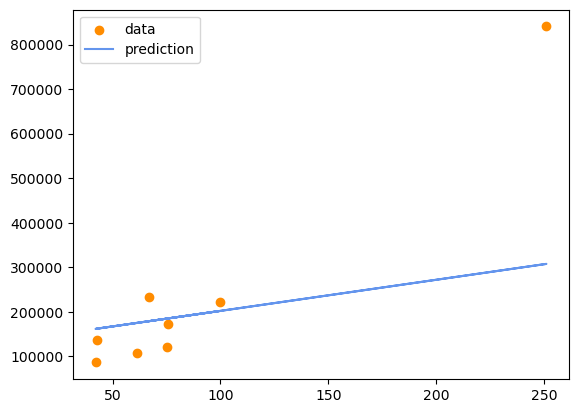

In [43]:
from sklearn.svm import SVR
# create an SVR model with a linear kernel 
svr = SVR(kernel='linear') 
  
# train the model on the data 
svr.fit(X_train, y_train) 
  
# make predictions on the data 
y_pred = svr.predict(X_test) 
  
# plot the predicted values against the true values 
plt.scatter(X_test, y_test, color='darkorange', 
            label='data') 
plt.plot(X_test, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

<h1> Как будто значительно лучше чем обычная линейная регрессия <h1>

<h1> SVM Polynomial Kernel<h1>

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


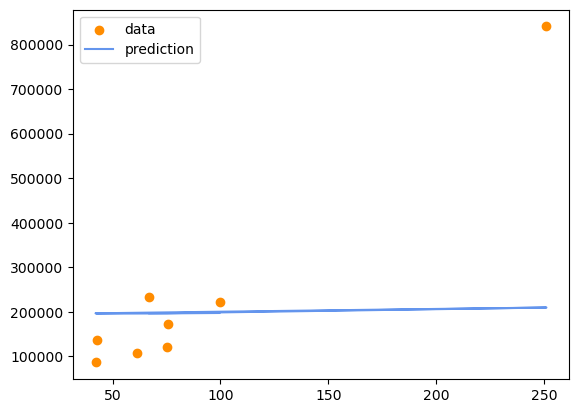

In [44]:
# create an SVR model with a linear kernel 
svr = SVR(kernel='poly')
# train the model on the data 
svr.fit(X_train, y_train) 
  
# make predictions on the data 
y_pred = svr.predict(X_test) 
  
# plot the predicted values against the true values 
plt.scatter(X_test, y_test, color='darkorange', 
            label='data') 
plt.plot(X_test, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

<h1> Уберем выброс <h1>

In [69]:
X_test = np.delete(X_test, 6, axis=0)
X_test.shape

(7, 1)

In [70]:
y_test = np.delete(y_test, 6, axis=0)
y_test.shape

(7, 1)

<h1> Повторим метод опорных векторов<h1>

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


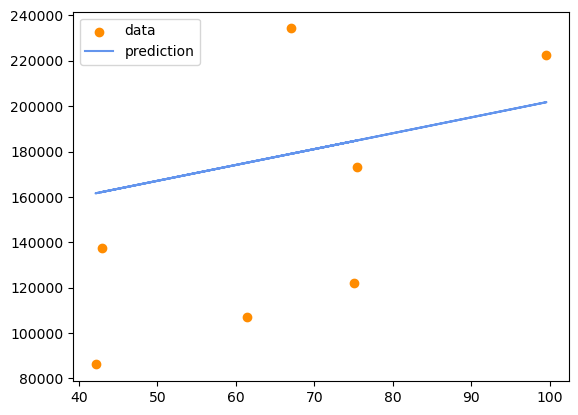

In [71]:
from sklearn.svm import SVR
# create an SVR model with a linear kernel 
svr = SVR(kernel='linear') 
  
# train the model on the data 
svr.fit(X_train, y_train) 
  
# make predictions on the data 
y_pred = svr.predict(X_test) 
  
# plot the predicted values against the true values 
plt.scatter(X_test, y_test, color='darkorange', 
            label='data') 
plt.plot(X_test, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


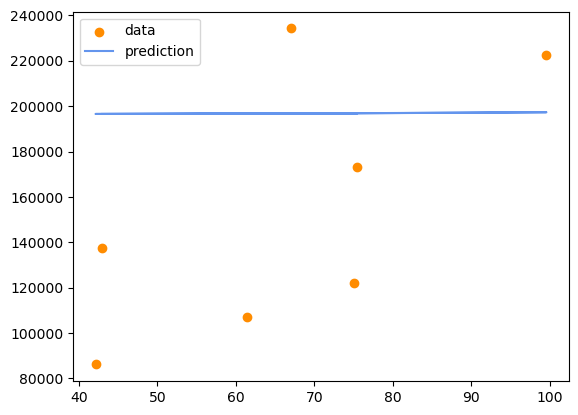

In [72]:
# create an SVR model with a linear kernel 
svr = SVR(kernel='poly')
# train the model on the data 
svr.fit(X_train, y_train) 
  
# make predictions on the data 
y_pred = svr.predict(X_test) 
  
# plot the predicted values against the true values 
plt.scatter(X_test, y_test, color='darkorange', 
            label='data') 
plt.plot(X_test, y_pred, color='cornflowerblue', 
         label='prediction') 
plt.legend() 
plt.show() 

<h1> Непонятно что происходит с полиномиальным ядром<h1>

In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import keras
from keras import layers

In [17]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [18]:
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

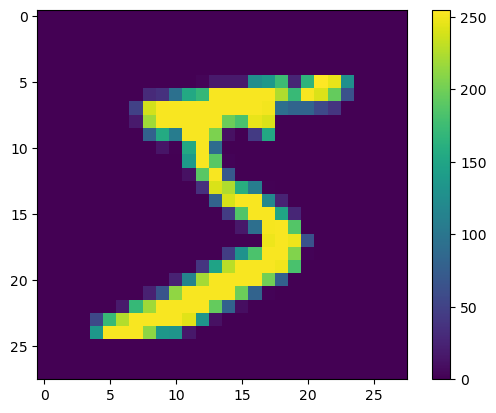

In [28]:
plt.figure()
plt.imshow(x_train[0])
plt.colorbar()
plt.grid(False)

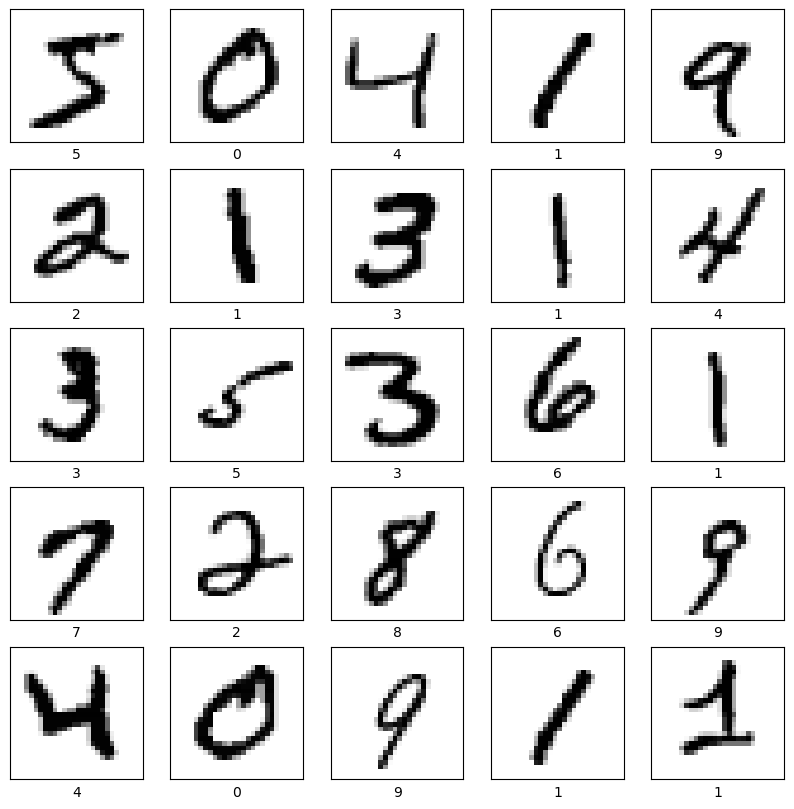

In [30]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])

In [31]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

C:\Users\vboro\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model.compile(optimizer=tf.optimizers.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [33]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 682us/step - accuracy: 0.8064 - loss: 6.9823
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.9017 - loss: 0.4203
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.9269 - loss: 0.2886
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step - accuracy: 0.9341 - loss: 0.2594
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - accuracy: 0.9404 - loss: 0.2342


In [34]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.9360 - loss: 0.3006
Test accuracy: 0.942799985408783


In [35]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step


In [36]:
predictions[0]

array([9.8059019e-17, 1.6804946e-16, 2.5078697e-07, 5.1451335e-12,
       1.1534296e-12, 4.0570859e-11, 0.0000000e+00, 9.9999976e-01,
       6.4331796e-23, 3.6018181e-11], dtype=float32)

In [44]:
confusion_mat = confusion_matrix(y_test,np.argmax(predictions,axis=1))
confusion_mat

array([[ 965,    1,    1,    1,    1,    0,    1,    1,    9,    0],
       [   0, 1120,    2,    3,    0,    2,    1,    1,    6,    0],
       [  12,   11,  933,    3,    0,    6,    5,   18,   43,    1],
       [   1,    0,    5,  939,    0,   13,    0,    9,   38,    5],
       [   0,    1,    4,    0,  913,    0,    4,   11,   22,   27],
       [   4,    0,    1,   28,    0,  800,    5,    5,   44,    5],
       [  10,    3,    5,    0,   14,   12,  905,    0,    9,    0],
       [   1,    6,    7,    0,    3,    1,    0,  992,    7,   11],
       [   4,    2,    0,    5,    4,    6,    5,    5,  938,    5],
       [   6,    5,    1,    9,   12,    3,    1,   15,   34,  923]],
      dtype=int64)

<Axes: >

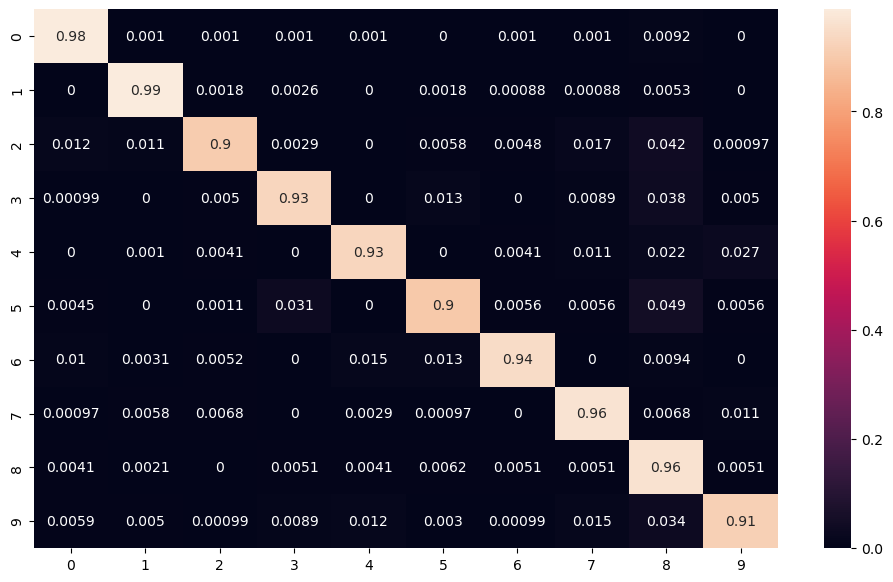

In [46]:
classes = ['0','1','2','3','4','5','6','7','8','9']
df_cm = pd.DataFrame(confusion_mat / np.sum(confusion_mat, axis=1)[:, None], index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sns.heatmap(df_cm, annot=True)